In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv

load_dotenv(Path('..') / '.env')
sys.path.insert(0, str(Path('.')))

from cohort_retention.cohort import build_cohort_matrix
from cohort_retention.retention import fit_retention_curve, retention_by_channel

In [2]:
# Constants
DATA_DIR = Path('..') / 'data' / 'synthetic'
COHORT_START = '2024-01-01'
MAX_PERIODS = 20

In [3]:
events = pd.read_csv(DATA_DIR / 'events.csv', parse_dates=['occurred_at'])
users  = pd.read_csv(DATA_DIR / 'users.csv',  parse_dates=['signup_at', 'churn_at'])

Power law fit: a=0.245, b=0.259
R² = 0.927
Estimated 1-year retention: 8.7%


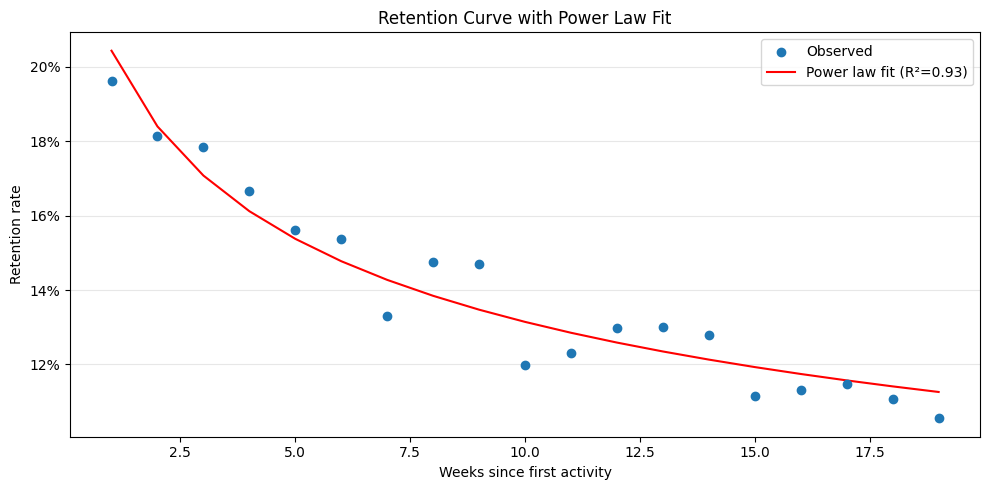

In [4]:
# Fit power-law retention curve
matrix = build_cohort_matrix(events, max_periods=MAX_PERIODS)
avg = matrix.mean(axis=0).dropna()

fit = fit_retention_curve(avg, model='power_law')
print(f"Power law fit: a={fit['params'][0]:.3f}, b={fit['params'][1]:.3f}")
print(f"R² = {fit['r_squared']:.3f}")
print(f"Estimated 1-year retention: {fit['long_run_estimate']:.1%}")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
obs_x = avg.index[avg.index > 0]
obs_y = avg[obs_x]
ax.scatter(obs_x, obs_y, label='Observed', zorder=5)
ax.plot(obs_x, fit['fitted'], color='red', label=f"Power law fit (R²={fit['r_squared']:.2f})")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_xlabel('Weeks since first activity')
ax.set_ylabel('Retention rate')
ax.set_title('Retention Curve with Power Law Fit')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

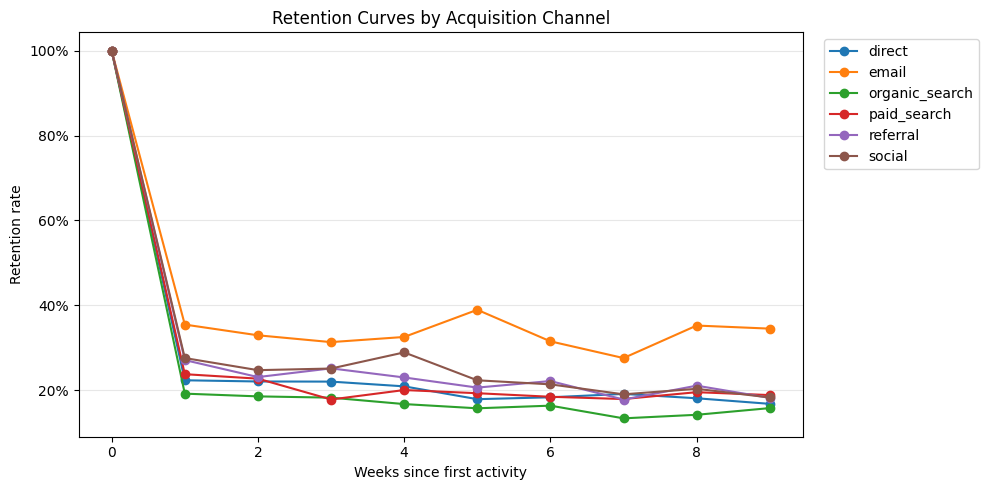

In [5]:
# Retention by acquisition channel
channel_ret = retention_by_channel(users, events, periods=10)

fig, ax = plt.subplots(figsize=(10, 5))
for _, row in channel_ret.iterrows():
    periods = [c for c in row.index if isinstance(c, int)]
    ax.plot(periods, row[periods].values, marker='o', label=row['channel'])

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_xlabel('Weeks since first activity')
ax.set_ylabel('Retention rate')
ax.set_title('Retention Curves by Acquisition Channel')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()